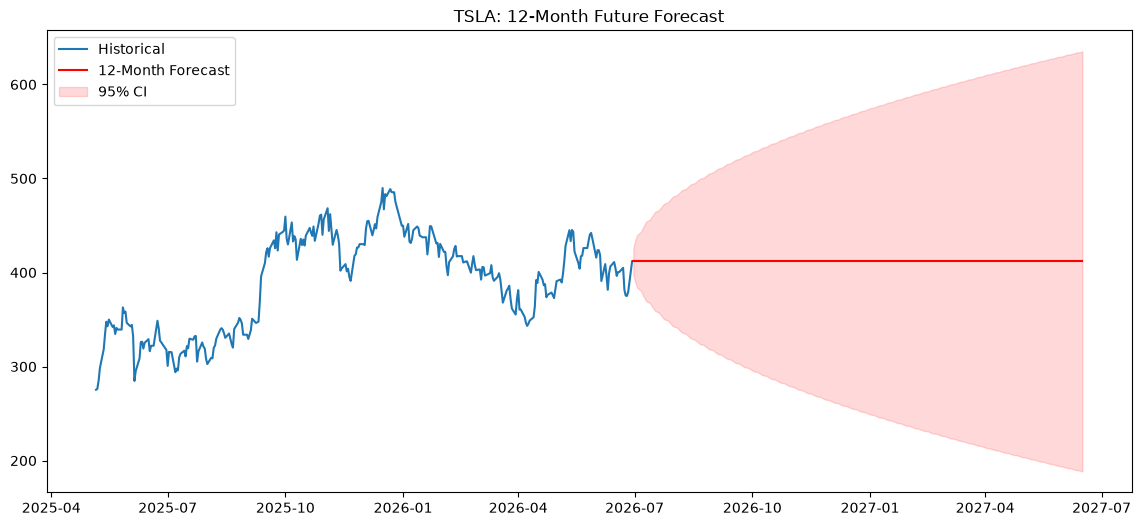

Forecast range: 188.52 to 635.16 by 2027-06-16


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA

tsla = pd.read_csv("../data/processed/TSLA.csv", index_col="Date", parse_dates=True)
tsla = tsla.asfreq("B")
tsla["Close"] = tsla["Close"].ffill()

# Refit on ALL available data (train+test) for the true future forecast
final_model = ARIMA(tsla["Close"], order=(0, 1, 0))
final_fitted = final_model.fit()

FORECAST_DAYS = 252  # ~12 months of trading days
forecast_result = final_fitted.get_forecast(steps=FORECAST_DAYS)
forecast_mean = forecast_result.predicted_mean
conf_int = forecast_result.conf_int(alpha=0.05)

future_dates = pd.bdate_range(start=tsla.index[-1] + pd.Timedelta(days=1), periods=FORECAST_DAYS)
forecast_mean.index = future_dates
conf_int.index = future_dates

plt.figure(figsize=(14, 6))
plt.plot(tsla.index[-300:], tsla["Close"].iloc[-300:], label="Historical")
plt.plot(forecast_mean.index, forecast_mean, label="12-Month Forecast", color="red")
plt.fill_between(conf_int.index, conf_int.iloc[:, 0], conf_int.iloc[:, 1], color="red", alpha=0.15, label="95% CI")
plt.title("TSLA: 12-Month Future Forecast")
plt.legend()
plt.savefig("../data/processed/future_forecast.png", dpi=150)
plt.show()

print(f"Forecast range: {conf_int.iloc[-1,0]:.2f} to {conf_int.iloc[-1,1]:.2f} by {future_dates[-1].date()}")